In [1]:
# Import Required Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load and Preprocess the MNIST Dataset
from tensorflow.keras.datasets import mnist

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Expand dimensions to match the input shape of the CNN
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [3]:
# Define the CNN Model
from tensorflow.keras import layers, models

def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

cnn_model = create_cnn_model()
cnn_model.summary()

c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Implement Self-Supervised Learning
def rotate_images(images, labels):
    rotations = [0, 90, 180, 270]
    rotated_images = []
    rotation_labels = []
    
    for img in images:
        for i, angle in enumerate(rotations):
            rotated_img = tf.image.rot90(img, k=i)
            rotated_images.append(rotated_img)
            rotation_labels.append(i)
    
    return np.array(rotated_images), np.array(rotation_labels)

# Create a self-supervised dataset
rotated_x_train, rotation_y_train = rotate_images(x_train, y_train)
rotated_x_test, rotation_y_test = rotate_images(x_test, y_test)

In [8]:
# Apply Few-Shot Learning
few_shot_indices = np.random.choice(len(x_train), size=100, replace=False)
few_shot_x_train = x_train[few_shot_indices]
few_shot_y_train = y_train[few_shot_indices]

# # Fine-tune the model on the few-shot dataset
# cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# cnn_model.fit(few_shot_x_train, few_shot_y_train, epochs=5)

In [ ]:
# Train the Model
# Pre-train on the self-supervised task
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(rotated_x_train, rotation_y_train, epochs=10)


Epoch 1/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9783 - loss: 0.0614
Epoch 2/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9954 - loss: 0.0133
Epoch 3/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9959 - loss: 0.0121
Epoch 4/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9963 - loss: 0.0111
Epoch 5/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9962 - loss: 0.0111
Epoch 6/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9962 - loss: 0.0104
Epoch 7/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9968 - loss: 0.0096
Epoch 8/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9970 - loss: 0.0091
Epoch 9/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9970 - loss: 0.0090
Epoch 10/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9971 - loss: 0.0092
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0685 - loss: 71.5398  
Epoch 2/5
4/4 ━━━━━━━━━━━

In [ ]:
# Fine-tune on the few-shot dataset
cnn_model.fit(few_shot_x_train, few_shot_y_train, epochs=50)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8280 - loss: 0.5882
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8367 - loss: 0.6288 
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8608 - loss: 0.5975
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8765 - loss: 0.5564 
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8523 - loss: 0.6069 
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8422 - loss: 0.5996 
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8058 - loss: 0.5953 
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8244 - loss: 0.5457
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8462 - loss: 0.5544
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8339 - loss: 0.5232 
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8275 - loss: 0.5291
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8605 - loss: 0.5427
E

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5514 - loss: 2.5309
Test Accuracy: 55.45%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


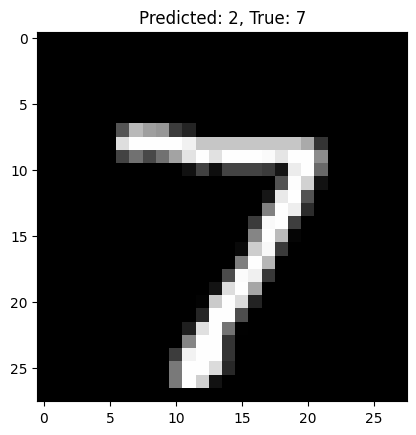

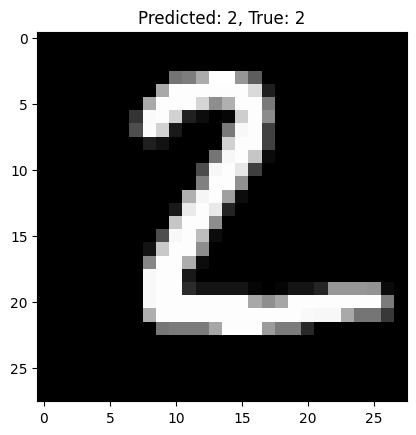

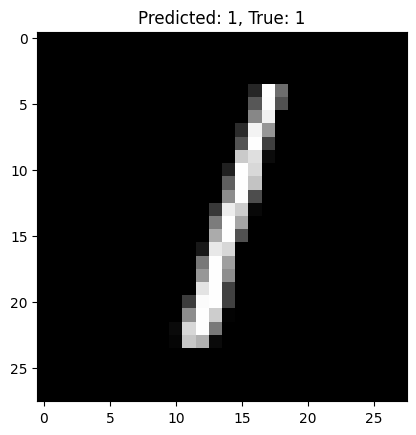

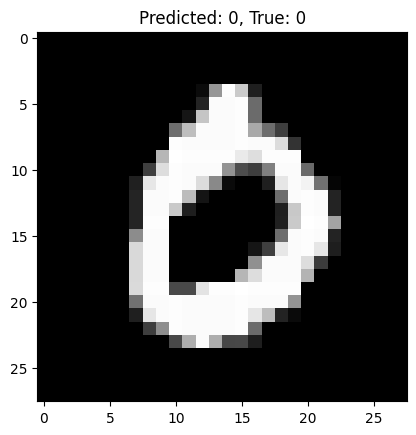

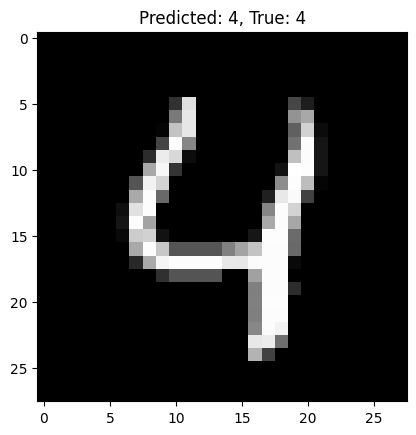

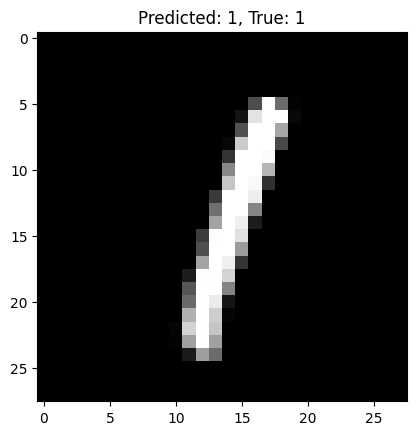

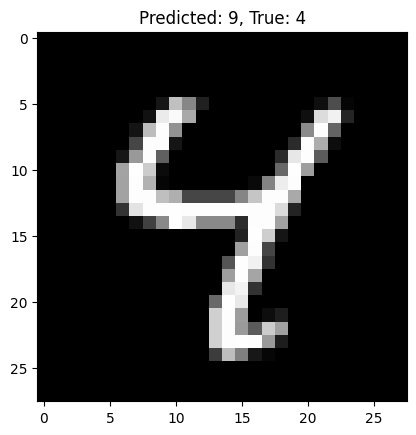

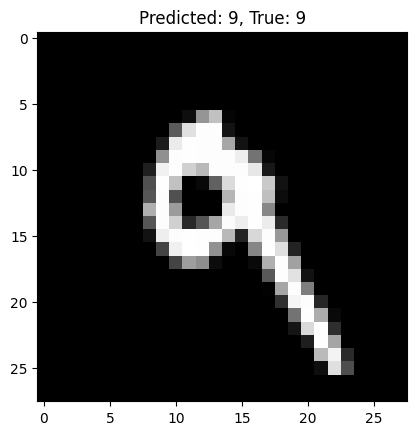

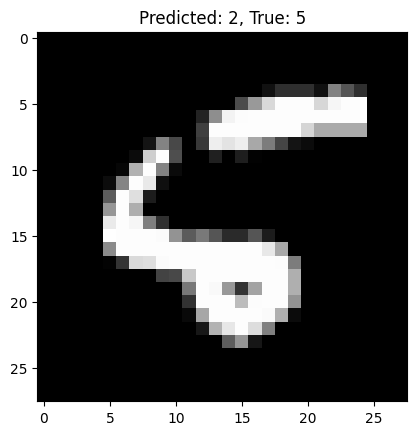

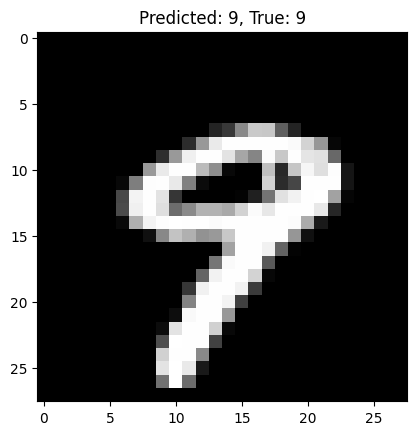

In [13]:
# Evaluate the Model
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Visualize some predictions
predictions = cnn_model.predict(x_test[:10])
for i, pred in enumerate(predictions):
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f"Predicted: {np.argmax(pred)}, True: {y_test[i]}")
    plt.show()